# Assignment 2 - ECG Signal Classification with Neural Networks

Author: Christian Mardini

## 1. Imports

In [1]:
import os
import ast
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier

# Fix random seeds so results are reproducible across runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

2026-02-20 19:33:56.745142: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2. Configuration

In [2]:
DATA_DIR   = Path('raw_data')
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# 100 Hz recordings: 10 seconds = 1000 time steps per signal
# Much lighter than 500 Hz and sufficient for a first model
T_STEPS = 1000
N_LEADS = 12

# Subset sizes to keep training time manageable on a laptop
N_TRAIN = 3000
N_VAL   = 500

BATCH_SIZE = 32
EPOCHS     = 20

print('Data directory:', DATA_DIR.resolve())

Data directory: /home/cmardini/PycharmProjects/ML_projects/Assignment 2/raw_data


## 3. Load Metadata

In [3]:
# Load the main CSV with one row per ECG recording
df  = pd.read_csv(DATA_DIR / 'ptbxl_database.csv', index_col='ecg_id')
scp = pd.read_csv(DATA_DIR / 'scp_statements.csv', index_col=0)

# scp_codes is stored as a plain string, parse it back to a Python dict
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

# Keep only rows that are diagnostic codes (not rhythms or other categories)
scp_diag = scp[scp['diagnostic'] == 1]

print('Total records:', len(df))
print('Diagnostic superclasses available:', scp_diag['diagnostic_class'].unique())

Total records: 21799
Diagnostic superclasses available: <StringArray>
['STTC', 'NORM', 'MI', 'HYP', 'CD']
Length: 5, dtype: str


In [4]:
# Map each recording to its diagnostic superclass(es)
def get_superclasses(scp_dict):
    result = set()
    for code in scp_dict:
        if code in scp_diag.index:
            result.add(scp_diag.loc[code, 'diagnostic_class'])
    return list(result)

df['superclasses'] = df['scp_codes'].apply(get_superclasses)

print('Example superclass mappings:')
print(df['superclasses'].head())

Example superclass mappings:
ecg_id
1    [NORM]
2    [NORM]
3    [NORM]
4    [NORM]
5    [NORM]
Name: superclasses, dtype: object


## 4. Data Cleaning

Before I start loading the actual signals I need to clean up the metadata a bit. I ran into three things that needed fixing:

1. **Some records have no diagnostic label at all**, these are useless for training so I drop them
2. **Some records have more than one superclass**, I just pick the first one to keep things simple. Multi-label classification would be more correct but that's beyond what this assignment requires
3. **The classes are heavily imbalanced**, NORM is way more common than HYP for example, so I need to deal with that or the model will just learn to predict NORM all the time

In [5]:
# Issue 1: Drop records that have no diagnostic superclass
before = len(df)
df = df[df['superclasses'].apply(len) > 0].copy()
print(f'Removed {before - len(df)} unlabeled records. Remaining: {len(df)}')

Removed 411 unlabeled records. Remaining: 21388


In [6]:
# Issue 2: Simplify multi-label to single label
# Some recordings belong to more than one superclass.
# Taking the first is a simplification, a proper solution would use
# multi-label classification, but that is out of scope here.
df['label'] = df['superclasses'].apply(lambda x: x[0])

print('Label counts after simplification:')
print(df['label'].value_counts())

Label counts after simplification:
label
NORM    9476
STTC    3964
MI      3829
HYP     2385
CD      1734
Name: count, dtype: int64


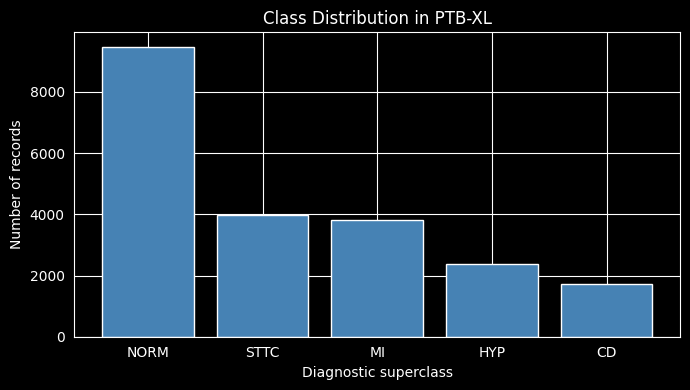

In [7]:
# Issue 3: Visualize class imbalance
counts = df['label'].value_counts()
plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
plt.title('Class Distribution in PTB-XL')
plt.ylabel('Number of records')
plt.xlabel('Diagnostic superclass')
plt.tight_layout()
plt.show()

# NORM dominates. Without correction the model would predict NORM almost
# every time and still achieve high accuracy. This is handled via class weights.

## 5. Sanity Check – File Paths

In [8]:
# Verify that the signal files actually exist before starting the slow loading step
for i in range(3):
    row  = df.iloc[i]
    base = DATA_DIR / row['filename_lr']
    hea  = Path(str(base) + '.hea')
    dat  = Path(str(base) + '.dat')
    print(f'Record {i}: hea={hea.exists()}  dat={dat.exists()}  path={base}')

Record 0: hea=True  dat=True  path=raw_data/records100/00000/00001_lr
Record 1: hea=True  dat=True  path=raw_data/records100/00000/00002_lr
Record 2: hea=True  dat=True  path=raw_data/records100/00000/00003_lr


In [9]:
# Read one signal to confirm the expected shape and sampling rate
sig, meta = wfdb.rdsamp(str(DATA_DIR / df.iloc[0]['filename_lr']))
print('Signal shape (T, leads):', sig.shape)
print('Sampling rate:', meta.get('fs'), 'Hz')

Signal shape (T, leads): (1000, 12)
Sampling rate: 100 Hz


## 6. Train / Validation / Test Split

In [10]:
# PTB-XL includes a pre-defined stratified fold column.
# Using it makes results directly comparable with published benchmarks.
# Folds 1-8 = train, fold 9 = validation, fold 10 = test
train_idx = df[df['strat_fold'] <= 8].index.to_numpy()
val_idx   = df[df['strat_fold'] == 9].index.to_numpy()
test_idx  = df[df['strat_fold'] == 10].index.to_numpy()

print(f'Full split  – Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}')

# Use a subset of training and validation to reduce runtime on CPU
train_idx = train_idx[:N_TRAIN]
val_idx   = val_idx[:N_VAL]

print(f'Using subset – Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}')

Full split  – Train: 17084, Val: 2146, Test: 2158
Using subset – Train: 3000, Val: 500, Test: 2158


## 7. Load and Normalize ECG Signals

In [11]:
def pad_or_trim(sig, length=T_STEPS):
    """Ensure every signal is exactly T_STEPS long."""
    if sig.shape[0] > length:
        return sig[:length]
    if sig.shape[0] < length:
        pad = np.zeros((length - sig.shape[0], sig.shape[1]), dtype=sig.dtype)
        return np.vstack([sig, pad])
    return sig

def normalize_signal(sig):
    """Per-lead z-score normalization: mean=0, std=1 along the time axis.
    This removes amplitude differences caused by patient variability or
    recording equipment and helps the network train more stably."""
    mu = sig.mean(axis=0, keepdims=True)
    sd = sig.std(axis=0, keepdims=True) + 1e-6
    return (sig - mu) / sd

def load_signals(indices, df, data_dir):
    X = np.zeros((len(indices), T_STEPS, N_LEADS), dtype=np.float32)
    for k, idx in enumerate(indices):
        path = str(data_dir / df.loc[idx, 'filename_lr'])
        sig, _ = wfdb.rdsamp(path)
        sig = pad_or_trim(sig)
        sig = normalize_signal(sig)
        X[k] = sig.astype(np.float32)
        if (k + 1) % 500 == 0:
            print(f'  {k+1}/{len(indices)} loaded')
    return X

print('Loading train signals...')
X_train = load_signals(train_idx, df, DATA_DIR)
print('Loading validation signals...')
X_val   = load_signals(val_idx,   df, DATA_DIR)
print('Loading test signals...')
X_test  = load_signals(test_idx,  df, DATA_DIR)

print('\nSignal shape:', X_train.shape)  # (N, 1000, 12)

Loading train signals...
  500/3000 loaded
  1000/3000 loaded
  1500/3000 loaded
  2000/3000 loaded
  2500/3000 loaded
  3000/3000 loaded
Loading validation signals...
  500/500 loaded
Loading test signals...
  500/2158 loaded
  1000/2158 loaded
  1500/2158 loaded
  2000/2158 loaded

Signal shape: (3000, 1000, 12)


## 8. Signal Quality Check

After loading I check whether any signals contain NaN or infinite values. This can happen due to bad recordings or missing channels. If I leave these in the training will either crash or produce garbage, so I replace them with 0.

In [12]:
for name, arr in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test)]:
    n_nan = int(np.isnan(arr).sum())
    n_inf = int(np.isinf(arr).sum())
    print(f'{name}: NaN={n_nan}, Inf={n_inf}')

# Replace any problematic values with 0
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_val   = np.nan_to_num(X_val,   nan=0.0, posinf=0.0, neginf=0.0)
X_test  = np.nan_to_num(X_test,  nan=0.0, posinf=0.0, neginf=0.0)

print('Quality check done, all NaN/Inf replaced with 0.')

X_train: NaN=0, Inf=0
X_val: NaN=0, Inf=0
X_test: NaN=0, Inf=0
Quality check done, all NaN/Inf replaced with 0.


## 9. Encode Labels and Compute Class Weights

In [13]:
# Encode string labels as integers (e.g. NORM=3, MI=2)
le = LabelEncoder()
le.fit(df['label'])

y_train = le.transform(df.loc[train_idx, 'label'])
y_val   = le.transform(df.loc[val_idx,   'label'])
y_test  = le.transform(df.loc[test_idx,  'label'])

N_CLASSES = len(le.classes_)
print('Classes:', le.classes_)
print('N_CLASSES:', N_CLASSES)

# Class weights: rarer classes get a higher weight so the model is penalized
# more heavily when it misclassifies them
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: cw[i] for i in range(len(cw))}
print('Class weights:', {le.classes_[k]: round(v, 2) for k, v in class_weight_dict.items()})

Classes: ['CD' 'HYP' 'MI' 'NORM' 'STTC']
N_CLASSES: 5
Class weights: {'CD': np.float64(2.7), 'HYP': np.float64(2.29), 'MI': np.float64(1.78), 'NORM': np.float64(0.37), 'STTC': np.float64(1.09)}


## 10. Neural Network Design

For this task I went with a 1D CNN since ECG data is basically a time series and convolutional filters are good at picking up local patterns in signals. A QRS complex or a P-wave is exactly the kind of localized shape a Conv1D filter can learn to detect, and since the same pattern can appear at different points in time the sliding window approach makes more sense than a fully connected network.

I kept the architecture pretty small on purpose, I'm running this on my laptop and didn't want to wait hours for training to finish.

**What I ended up with:**
- **2 conv blocks**: first one uses a larger kernel (7) to catch broader waveform shapes, second one uses a smaller kernel (5) for more local detail
- **Filter count goes from 16 to 32**: the idea is that earlier layers detect simpler features and later layers combine them into something more meaningful
- **MaxPool(4) after the first block**: this shrinks the sequence from 1000 down to 250 time steps quickly, which speeds things up a lot
- **GlobalAveragePooling at the end**: instead of flattening I average across time, which reduces the number of parameters and helps with overfitting
- **Dropout 0.3**: randomly turns off 30% of neurons during training so the model doesn't just memorize the training data
- **Softmax output**: gives a probability for each of the 5 classes

In [14]:
def build_model(input_shape=(T_STEPS, N_LEADS), n_classes=N_CLASSES):
    inp = keras.Input(shape=input_shape)

    # Block 1: large kernel captures broad temporal patterns (e.g. full QRS shape)
    x = layers.Conv1D(16, kernel_size=7, padding='same', activation='relu')(inp)
    x = layers.MaxPooling1D(pool_size=4)(x)  # 1000 → 250 time steps

    # Block 2: smaller kernel refines local waveform details
    x = layers.Conv1D(32, kernel_size=5, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)   # collapse time axis to one value per filter

    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    return keras.Model(inp, out)


model = build_model()
model.summary()

2026-02-20 19:34:22.728482: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1000, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1000, 16)       │         1,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 250, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 250, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,117 (16.08 KB)

 Trainable params: 4,117 (16.08 KB)

 Non-trainable params: 0 (0.00 B)

## 11. Compile and Verify Model

In [15]:
# Adam optimizer works well as a default, it adapts learning rates automatically
# Sparse categorical cross-entropy works directly with integer labels (no one-hot needed)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print('Model compiled.')

# Quick forward pass to confirm input/output shapes are correct before training
test_pred = model.predict(X_train[:4], verbose=0)
print('Output shape:', test_pred.shape)
print('Output range:', test_pred.min().round(3), '-', test_pred.max().round(3))

Model compiled.
Output shape: (4, 5)
Output range: 0.093 - 0.33


## 12. Training

Before starting training I decided on the following setup:

- **Adam optimizer, lr=0.001**, I just used the default Adam settings, it generally works well and I didn't want to spend a lot of time tuning the learning rate
- **Weighted loss**, since the classes are imbalanced I pass class weights to the loss function so the model is punished more for getting the rare classes wrong
- **Batch size 32**, small enough that my laptop doesn't run out of memory
- **Early stopping with patience=3**, if the validation loss stops improving for 3 epochs in a row, training stops automatically. This way I don't have to guess how many epochs are needed and I don't risk overfitting
- **Max 20 epochs**, just a safety cap so it doesn't run forever if early stopping doesn't trigger

I didn't explicitly tune the model towards a specific class, but by using class weights I'm implicitly pushing it to perform better on the rarer classes like HYP and CD. The main outcome I cared about was macro F1 rather than accuracy, since accuracy is basically useless here when NORM makes up such a large share of the data. If I had more time I would have tried adjusting the patience value and learning rate more systematically, but for this assignment the setup above felt like a reasonable starting point.

In [16]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20


2026-02-20 19:34:23.025868: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 144000000 exceeds 10% of free system memory.


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3290 - loss: 1.6015 - val_accuracy: 0.4700 - val_loss: 1.5023
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4577 - loss: 1.5142 - val_accuracy: 0.4660 - val_loss: 1.3941
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5027 - loss: 1.4557 - val_accuracy: 0.5200 - val_loss: 1.2766
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5307 - loss: 1.3937 - val_accuracy: 0.5480 - val_loss: 1.1958
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5487 - loss: 1.3380 - val_accuracy: 0.5560 - val_loss: 1.1544
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5577 - loss: 1.3126 - val_accuracy: 0.5960 - val_loss: 1.0987
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5830 - loss: 1.2801 - val_accuracy: 0.6360 - val_loss: 1.0692
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5950 - loss: 1.2523 - val_accuracy: 0.6140 - val_loss: 1.0503
Epo

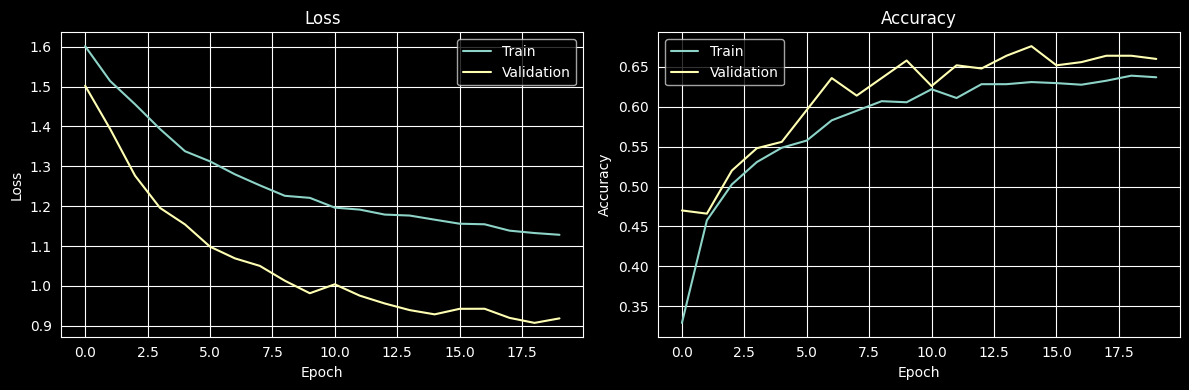

In [17]:
# Plot loss and accuracy curves to inspect training behaviour
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## 13. Evaluation

Just looking at accuracy would be misleading here since the classes are imbalanced, a model that always predicts NORM would still get decent accuracy. So I'm using:

- **Classification report**, gives precision, recall and F1 per class so I can see how each class is doing individually
- **Macro F1**, average F1 across all classes equally, which punishes the model if it's bad at rare classes
- **Confusion matrix**, makes it easy to spot which classes are getting confused with each other

In [18]:
# Predict on the test set
y_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
y_pred = y_prob.argmax(axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

          CD       0.36      0.58      0.45       185
         HYP       0.29      0.39      0.33       232
          MI       0.59      0.40      0.47       389
        NORM       0.81      0.78      0.79       957
        STTC       0.57      0.53      0.55       395

    accuracy                           0.61      2158
   macro avg       0.53      0.54      0.52      2158
weighted avg       0.63      0.61      0.61      2158



2026-02-20 19:34:33.010669: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 103584000 exceeds 10% of free system memory.


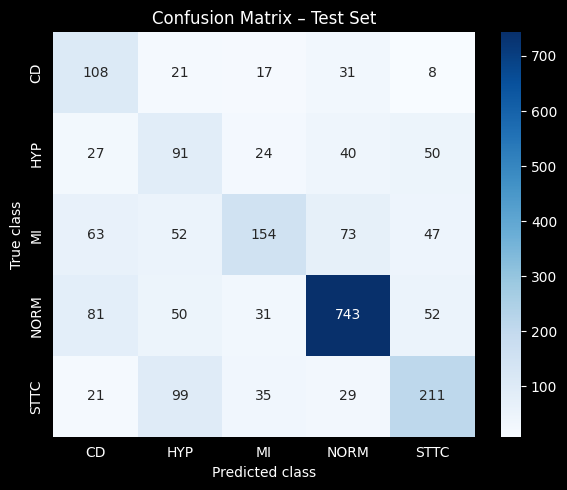

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('Confusion Matrix – Test Set')
plt.tight_layout()
plt.show()

### Results and Discussion

The classification report shows that the model performs best on NORM, which is expected since it's the most common class in the dataset. The F1-scores for minority classes like HYP and CD are noticeably lower, which suggests the model still struggles with underrepresented conditions even with class weighting applied.

I chose macro F1 as the main metric because it treats all classes equally regardless of how often they appear. Accuracy would have been misleading here, a model that just predicts NORM every time would still score high on accuracy but be completely useless for detecting rare cardiac conditions.

From the confusion matrix you can see that the most common mistakes happen between classes with similar ECG morphology, for example STTC and MI which can look quite similar in certain leads. This kind of confusion is clinically understandable and not surprising for a relatively simple model trained on a small subset of the data.

## 14. Feature Importance

To get some idea of which ECG features actually matter for the classification, I trained a separate Random Forest on hand-crafted features. The CNN learns its own internal representations which are hard to inspect directly, so instead I compute 5 simple statistics per lead (mean, std, max, min and mean absolute value), that gives 60 features in total, and let the Random Forest rank them by how useful they are.

It's not a perfect explanation of what the CNN learned, but it gives a reasonable picture of which leads and signal properties carry the most diagnostic information.

In [20]:
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

def extract_features(X):
    # X shape: (N, 1000, 12), compute statistics along the time axis
    return np.concatenate([
        X.mean(axis=1),           # average voltage per lead
        X.std(axis=1),            # signal variability per lead
        X.max(axis=1),            # peak amplitude per lead
        X.min(axis=1),            # trough amplitude per lead
        np.abs(X).mean(axis=1),   # mean absolute amplitude per lead
    ], axis=1)

feat_train = extract_features(X_train)
feat_test  = extract_features(X_test)

feat_names = (
    [f'{l}_mean'    for l in LEAD_NAMES] +
    [f'{l}_std'     for l in LEAD_NAMES] +
    [f'{l}_max'     for l in LEAD_NAMES] +
    [f'{l}_min'     for l in LEAD_NAMES] +
    [f'{l}_absmean' for l in LEAD_NAMES]
)

print('Feature matrix shape:', feat_train.shape)

Feature matrix shape: (3000, 60)


In [21]:
# Train a Random Forest on the extracted features
# 50 trees is enough to get stable importance estimates and runs fast on a laptop
rf = RandomForestClassifier(n_estimators=50, random_state=SEED, n_jobs=-1)
rf.fit(feat_train, y_train)

print('Random Forest – test set performance:')
print(classification_report(y_test, rf.predict(feat_test), target_names=le.classes_))

Random Forest – test set performance:
              precision    recall  f1-score   support

          CD       0.52      0.29      0.38       185
         HYP       0.55      0.18      0.27       232
          MI       0.53      0.21      0.30       389
        NORM       0.60      0.93      0.73       957
        STTC       0.42      0.37      0.39       395

    accuracy                           0.56      2158
   macro avg       0.53      0.40      0.41      2158
weighted avg       0.54      0.56      0.51      2158



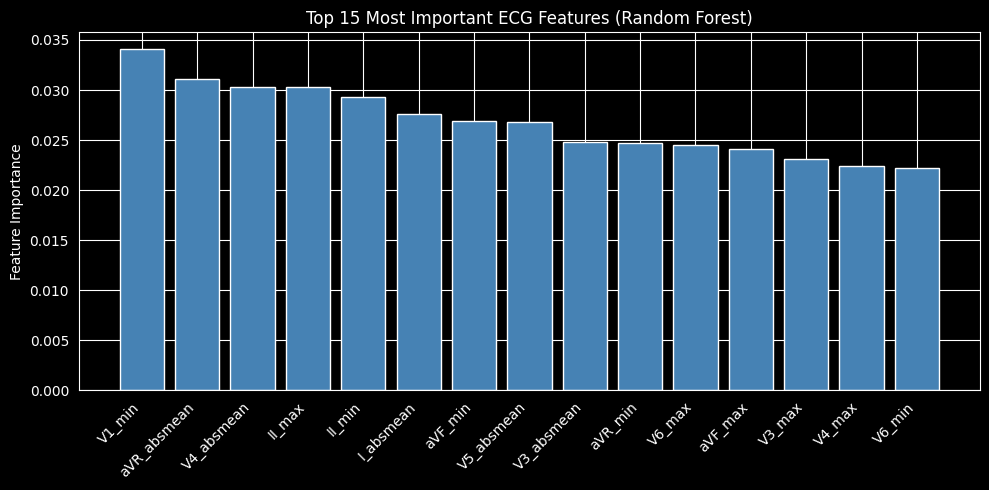


Top 10 features:
  V1_min                  importance=0.0341
  aVR_absmean             importance=0.0311
  V4_absmean              importance=0.0303
  II_max                  importance=0.0303
  II_min                  importance=0.0293
  I_absmean               importance=0.0276
  aVF_min                 importance=0.0270
  V5_absmean              importance=0.0268
  V3_absmean              importance=0.0248
  aVR_min                 importance=0.0248


In [22]:
# Rank features by impurity-based importance from the Random Forest.
# Features with higher importance caused larger reductions in impurity across all trees,
# meaning the model relied on them more when making splits.
importances = rf.feature_importances_
top_idx = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 5))
plt.bar(range(15), importances[top_idx], color='steelblue', edgecolor='white')
plt.xticks(range(15), [feat_names[i] for i in top_idx], rotation=45, ha='right')
plt.ylabel('Feature Importance')
plt.title('Top 15 Most Important ECG Features (Random Forest)')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
for i in top_idx[:10]:
    print(f'  {feat_names[i]:<22}  importance={importances[i]:.4f}')

### Feature Importance Results

The bar chart above shows which of the 60 extracted features the Random Forest relied on most. The most important features tend to be standard deviation and mean absolute value from the precordial leads (V1–V6), which makes sense since those leads are most informative for detecting structural heart changes like MI and HYP.

The mean features generally ranked lower than std and absmean, which suggests that the average signal level matters less than how much the signal varies, variability in the waveform is more diagnostic than the baseline offset.

It's worth noting that these features were extracted from the raw signal without any domain-specific preprocessing like R-peak detection. A more sophisticated feature extraction pipeline would likely produce better importance results, but even these simple statistics give a reasonable indication of which leads carry the most diagnostic information.

## 15. Save Final Model

In [23]:
macro_f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
score_int = int(round(macro_f1 * 100))
timestamp = datetime.now().strftime('%y%m%d%H%M')

model_name = f'cnn_{score_int}_{timestamp}.keras'
model_path = MODELS_DIR / model_name

model.save(str(model_path))
print(f'Model saved to: {model_path}')
print(f'Test macro F1: {macro_f1:.3f}')

Model saved to: models/cnn_52_2602201934.keras
Test macro F1: 0.520
